In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#load datasets
salary_df = pd.read_csv("../../data/raw/job_salary_prediction_dataset.csv")
cost_of_living_df = pd.read_csv("../../data/raw/Cost_of_Living_Index_by_Country_2024.csv")

print(salary_df.shape)
print(cost_of_living_df.shape)

(250001, 10)
(121, 8)


In [4]:
salary_df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,93764
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,189123
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,165069


In [5]:
cost_of_living_df.head()

,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,1,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
1,2,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
2,3,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
3,4,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
4,5,Barbados,76.6,19.0,48.9,80.8,69.4,43.5


In [6]:
#Join country and location keys
# Rename columns in both salary and cost of living for consistency
salary_df = salary_df.rename(columns={"location": "country"})
cost_of_living_df = cost_of_living_df.rename(columns={"Country": "country"})

#Map country names to each other
country_map = {
    "USA": "United States",
    "UK": "United Kingdom"
}

salary_df["country"] = salary_df["country"].replace(country_map)

In [7]:
#Merge both datasets
merged_df = pd.merge(salary_df, cost_of_living_df, on="country", how="left")

#replace spaces to underscores
merged_df.columns = (merged_df.columns.str.strip().str.lower().str.replace(" ", "_"))

merged_df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,country,remote_work,certifications,salary,rank,cost_of_living_index,rent_index,cost_of_living_plus_rent_index,groceries_index,restaurant_price_index,local_purchasing_power_index
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,109413,118.0,21.2,5.6,13.7,23.8,15.1,82.6
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,93764,10.0,70.2,33.4,52.5,77.3,62.5,127.4
2,Frontend Developer,18.0,PhD,4.0,Media,Medium,Singapore,No,1.0,148123,4.0,76.7,67.2,72.1,74.6,50.4,111.1
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,189123,12.0,64.8,33.2,49.6,71.2,61.7,103.7
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,165069,25.0,59.3,20.9,40.9,60.8,54.7,122.6
5,AI Engineer,0.0,High School,4.0,Education,Enterprise,United States,No,2.0,180351,9.0,70.4,41.7,56.6,75.0,67.2,142.3
6,Backend Developer,6.0,High School,16.0,Manufacturing,Enterprise,Canada,No,3.0,165375,12.0,64.8,33.2,49.6,71.2,61.7,103.7
7,Machine Learning Engineer,4.0,Bachelor,18.0,Healthcare,Enterprise,Canada,Hybrid,5.0,202463,12.0,64.8,33.2,49.6,71.2,61.7,103.7
8,AI Engineer,5.0,Diploma,14.0,Telecom,Enterprise,Singapore,Yes,0.0,171834,4.0,76.7,67.2,72.1,74.6,50.4,111.1
9,Frontend Developer,18.0,PhD,2.0,Retail,Enterprise,India,Hybrid,5.0,128377,118.0,21.2,5.6,13.7,23.8,15.1,82.6


In [8]:
#Summary Statistics
print("\nMerged Data Types:")
print(merged_df.dtypes)

# Null counts
null_counts = merged_df.isnull().sum()
print("\nNull Counts:")
print(null_counts)

# Basic stats
print("\nDataset Description:")
print(merged_df.describe(include='all'))


Merged Data Types:
job_title                          object
experience_years                  float64
education_level                    object
skills_count                      float64
industry                           object
company_size                       object
country                            object
remote_work                        object
certifications                    float64
salary                              int64
rank                              float64
cost_of_living_index              float64
rent_index                        float64
cost_of_living_plus_rent_index    float64
groceries_index                   float64
restaurant_price_index            float64
local_purchasing_power_index      float64
dtype: object

Null Counts:
job_title                             1
experience_years                      1
education_level                       1
skills_count                          1
industry                              1
company_size                          

In [9]:
merged_df.isnull().sum()

job_title                             1
experience_years                      1
education_level                       1
skills_count                          1
industry                              1
company_size                          1
country                               1
remote_work                           1
certifications                        1
salary                                0
rank                              25066
cost_of_living_index              25066
rent_index                        25066
cost_of_living_plus_rent_index    25066
groceries_index                   25066
restaurant_price_index            25066
local_purchasing_power_index      25066
dtype: int64

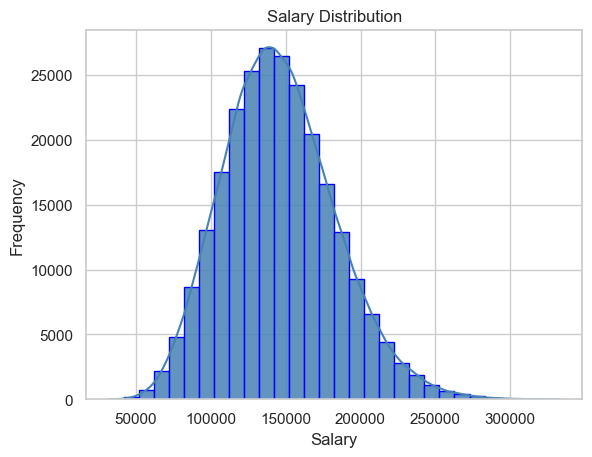

In [10]:
#EDA Visualizations
#Distribution of Salary
sns.set(style="whitegrid")

sns.histplot(merged_df["salary"], bins=30, kde=True, color="steelblue",edgecolor="blue", alpha=0.85)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

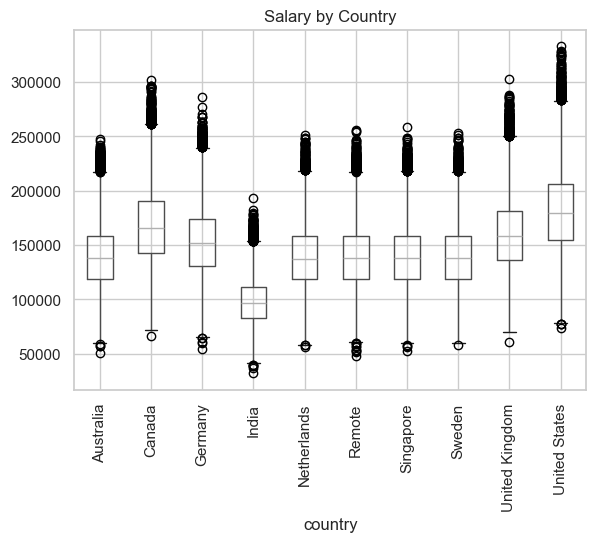

In [10]:
#Salary by Country Boxplots
merged_df.boxplot(column="salary", by="country", rot=90)
plt.title("Salary by Country")
plt.suptitle("")
plt.show()

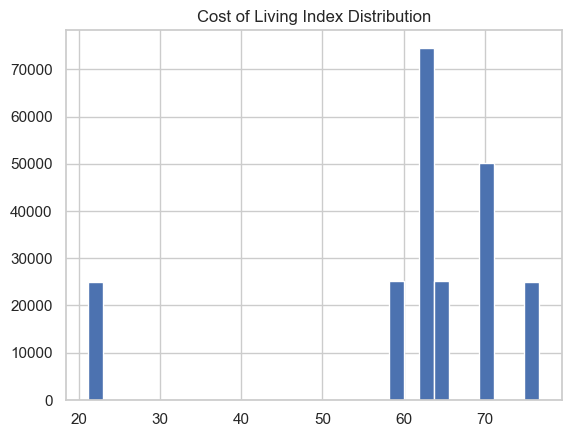

In [11]:
#Cost of Living Distribution
plt.hist(merged_df["cost_of_living_index"], bins=30)
plt.title("Cost of Living Index Distribution")
plt.show()

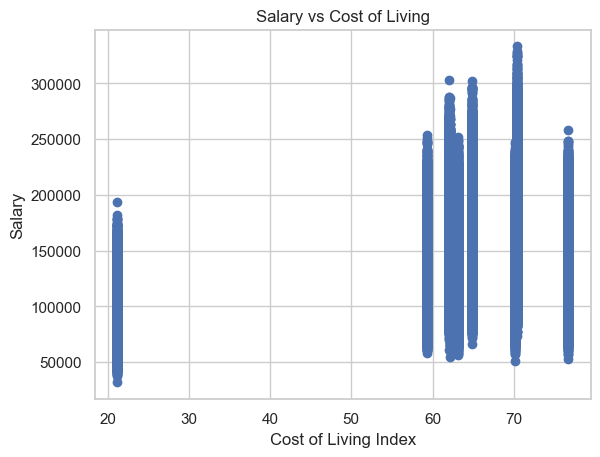

In [12]:
#Salary vs Cost of Living Scatterplot
plt.scatter(merged_df["cost_of_living_index"], merged_df["salary"])
plt.xlabel("Cost of Living Index")
plt.ylabel("Salary")
plt.title("Salary vs Cost of Living")
plt.show()

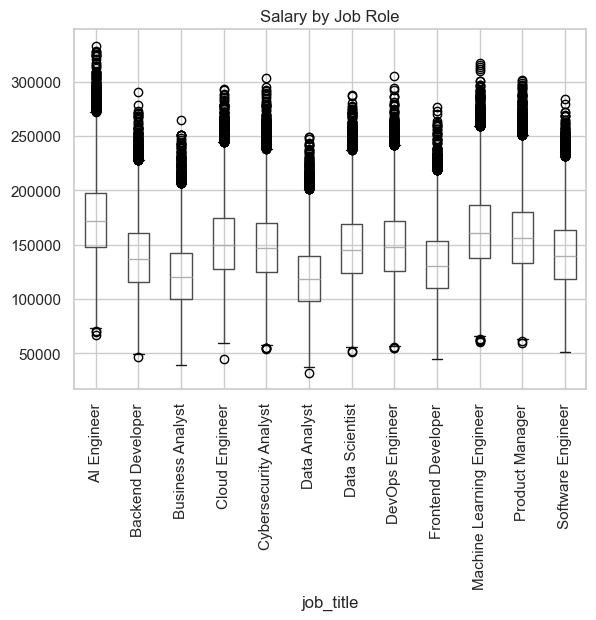

In [13]:
#Role based salaary
merged_df.boxplot(column="salary", by="job_title", rot=90)
plt.title("Salary by Job Role")
plt.suptitle("")
plt.show()

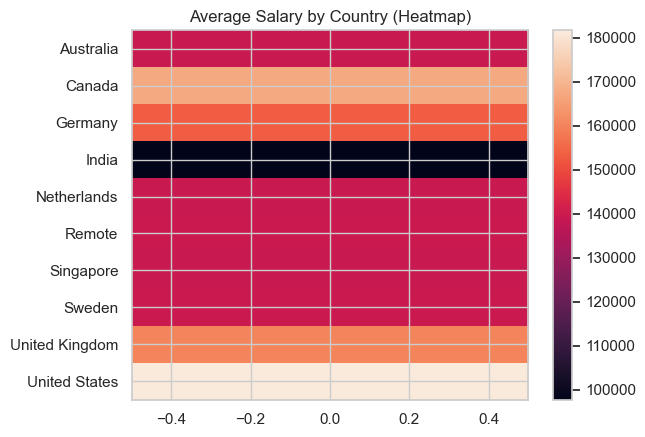

In [14]:
#Geo Heatmap
top_countries = merged_df["country"].value_counts().head(10).index
filtered = merged_df[merged_df["country"].isin(top_countries)]

pivot = filtered.pivot_table(
    values="salary",
    index="country",
    aggfunc="mean"
)

plt.imshow(pivot, aspect='auto')
plt.colorbar()
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Average Salary by Country (Heatmap)")
plt.show()

In [15]:
#Identify Outliers in Salary
Q1 = merged_df["salary"].quantile(0.25)
Q3 = merged_df["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

merged_df["outlier_flags"] = (
    (merged_df["salary"] < lower) | (merged_df["salary"] > upper)
)

In [16]:
#Export
merged_df.to_parquet("../../data/merged_data/merged.parquet", index=False)
merged_df.to_csv("../../data/merged_data/merged.csv", index=False)